In [3]:
!pip install python-dotenv langchain-huggingface huggingface_hub

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ------------------

In [4]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# Step 1: Load environment variables from .env file
load_dotenv()

# Step 2: Verify API Key is loaded
api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [6]:
!pip install langgraph


  Attempting uninstall: websockets

    Found existing installation: websockets 17.1

    Uninstalling websockets-17.1:

      Successfully uninstalled websockets-17.1

   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ---------------------------------------- 0/6 [websockets]
   ----------------------------------

In [7]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage
import json

In [42]:
class Blog(TypedDict):
    topic: str
    needs_research: bool
    research: str
    content: str

In [43]:
def research_decision(state: Blog):
    topic = state["topic"]

    # Temporary logic just for understanding the graph
    if "latest" in topic.lower() or "current" in topic.lower():
        return {"needs_research": True}

    return {"needs_research": False}

In [44]:
def route_research(state: Blog):
    if state["needs_research"]:
        return "research"

    return "generate-content"

In [45]:
def generate_content(state: Blog) -> Blog:
    title = state["topic"]
    api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",  # <-- Explicitly set the task expected by the provider
        max_new_tokens=512,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )

    chat_model = ChatHuggingFace(llm=llm)


    response = chat_model.invoke(f"Write a blog post about '{title}'.")
    return {"title": title, "content": response}

In [46]:
graph = StateGraph(Blog)

graph.add_node('generate-content', generate_content)
graph.add_node('research_decision', research_decision)
graph.add_node('research', route_research)

graph.add_edge(START, 'research_decision')
graph.add_conditional_edges("research_decision", route_research, {
    "research": "research",
    "generate-content": "generate-content"
})
graph.add_edge('research_decision', 'generate-content')
graph.add_edge('generate-content', END)
blog=graph.compile()

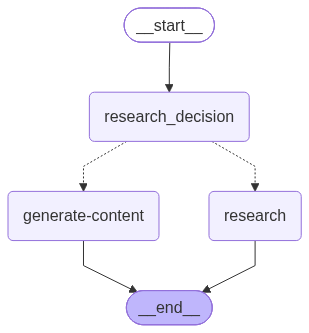

In [47]:
blog

In [51]:
result = blog.invoke({
    "topic": "Tell about self attention mechanism in deep learning",
})
print(result["content"].content)

**Self-Attention Mechanism in Deep Learning: A Game-Changer for Natural Language Processing**

In recent years, deep learning has revolutionized the field of natural language processing (NLP) with the advent of new architectures and techniques. One such innovation is the self-attention mechanism, which has become a crucial component in many state-of-the-art models. In this blog post, we'll delve into the world of self-attention and explore its applications in deep learning.

**What is Self-Attention?**

The self-attention mechanism, introduced by Vaswani et al. in 2017, is a technique used in NLP to allow models to attend to different parts of an input sequence simultaneously. Unlike traditional recurrent neural networks (RNNs), which process input sequences sequentially, self-attention models can consider the entire input sequence at once, making it more efficient and effective.

**Key Components of Self-Attention**

The self-attention mechanism consists of three main components:

1. 